In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Set font size and style in matplotlib
plt.rcParams.update({'font.size': 12, 'font.family': 'Arial'})

# Color palette - base and extended use same colors, different line styles
colors = ['#8E8E8E' ,'#C959C5', '#4FC452']

## Setup Extended Model

In [2]:
# Reload module to get latest changes
import importlib
import sys
if 'multi_nutrient_model_ext' in sys.modules:
    importlib.reload(sys.modules['multi_nutrient_model_ext'])

from multi_nutrient_model_glucagon import (
    ref_parameters as ref_parameters_ext,
    insulin_clamp_dynamic as insulin_clamp_dynamic_ext,
    TAU_INS as TAU_INS_ext,
    PO2, vO2, vATP, vE
)

# Extended model parameters
K_i_ketogenesis = 0.2
R_fatty_acids = 0.008
p_ext = ref_parameters_ext(K_i_ketogenesis=K_i_ketogenesis)

# Get insulin baseline
from multi_nutrient_model_glucagon import steady_state as steady_state_ext
x0_ext = steady_state_ext(1.0, p_ext)
I0_ext = x0_ext[4]

# Insulin levels
vI_low_ext = I0_ext / TAU_INS_ext  # Double basal fasted insulin levels
vI_high_ext = I0_ext / TAU_INS_ext * 3  # Three times low dose

# Common scaling factors (used for both models)
sK = 14/27  # Model accounts for about double the ketone oxidation
sL = 200/150
sGIR = vE * 180 * 1e-3

# Infusion rates (common for both models)
R_3HB = 120/vE * sK
R_lactate = 130/vE * sL

## Setup Base Model

In [3]:
# Import base model
import sys
sys.path.insert(0, '../multi_nutrient_model')
from multi_nutrient_model import (
    ref_parameters as ref_parameters_base,
    insulin_clamp_dynamic as insulin_clamp_dynamic_base,
    TAU_INS as TAU_INS_base,
    I0 as I0_base,
    PO2, vO2, vATP as vATP_base, vE as vE_base
)

# Base model parameters
p_base = ref_parameters_base(K_i_ketogenesis=K_i_ketogenesis)

# Insulin levels
vI_low_base = I0_base / TAU_INS_base
vI_high_base = I0_base / TAU_INS_base * 3

## Low Dose Insulin Clamp (1.25 mU)

Simulate saline, insulin only, and insulin + perturbation conditions.

In [4]:
# Simulation time
time = np.linspace(0, 120, 100)

# =============================================================================
# Extended Model - Low Dose
# =============================================================================

# Saline
x_saline_ext, GIR_saline_ext = insulin_clamp_dynamic_ext(0, time, 1.0, p=p_ext)

# Insulin only
x_insulin_low_ext, GIR_insulin_low_ext = insulin_clamp_dynamic_ext(vI_low_ext, time, 1.0, p=p_ext)

# Insulin + Intralipid
x_insulin_low_intralipid_ext, GIR_insulin_low_intralipid_ext = insulin_clamp_dynamic_ext(
    vI_low_ext, time, 1.0, p=p_ext, R_fatty_acids=R_fatty_acids)

# Insulin + 3HB
x_insulin_low_3HB_ext, GIR_insulin_low_3HB_ext = insulin_clamp_dynamic_ext(
    vI_low_ext, time, 1.0, p=p_ext, R_3HB=R_3HB)

# Insulin + Lactate
x_insulin_low_lactate_ext, GIR_insulin_low_lactate_ext = insulin_clamp_dynamic_ext(
    vI_low_ext, time, 1.0, p=p_ext, R_lactate=R_lactate)

# =============================================================================
# Base Model - Low Dose
# =============================================================================

# Saline
x_saline_base, GIR_saline_base = insulin_clamp_dynamic_base(0, time, 1.0, p=p_base)

# Insulin only
x_insulin_low_base, GIR_insulin_low_base = insulin_clamp_dynamic_base(vI_low_base, time, 1.0, p=p_base)

# Insulin + Intralipid
x_insulin_low_intralipid_base, GIR_insulin_low_intralipid_base = insulin_clamp_dynamic_base(
    vI_low_base, time, 1.0, p=p_base, R_fatty_acids=R_fatty_acids)

# Insulin + 3HB
x_insulin_low_3HB_base, GIR_insulin_low_3HB_base = insulin_clamp_dynamic_base(
    vI_low_base, time, 1.0, p=p_base, R_3HB=R_3HB)

# Insulin + Lactate
x_insulin_low_lactate_base, GIR_insulin_low_lactate_base = insulin_clamp_dynamic_base(
    vI_low_base, time, 1.0, p=p_base, R_lactate=R_lactate)

# =============================================================================
# Scale metabolites to physiological units
# =============================================================================

# Extended model
for df in [x_saline_ext, x_insulin_low_ext, x_insulin_low_intralipid_ext, 
           x_insulin_low_3HB_ext, x_insulin_low_lactate_ext]:
    df['K'] = df['K'] * 0.5  # mM
    df['L'] = df['L'] * 0.7  # mM

# Base model
for df in [x_saline_base, x_insulin_low_base, x_insulin_low_intralipid_base,
           x_insulin_low_3HB_base, x_insulin_low_lactate_base]:
    df['K'] = df['K'] * 0.5  # mM
    df['L'] = df['L'] * 0.7  # mM

# Scale GIR with common scaling factor
for df in [GIR_saline_ext, GIR_insulin_low_ext, GIR_insulin_low_intralipid_ext,
           GIR_insulin_low_3HB_ext, GIR_insulin_low_lactate_ext,
           GIR_saline_base, GIR_insulin_low_base, GIR_insulin_low_intralipid_base,
           GIR_insulin_low_3HB_base, GIR_insulin_low_lactate_base]:
    df['GIR'] = df['GIR'] * sGIR

## Comparison Plots - Low Dose Insulin (1.25 mU)

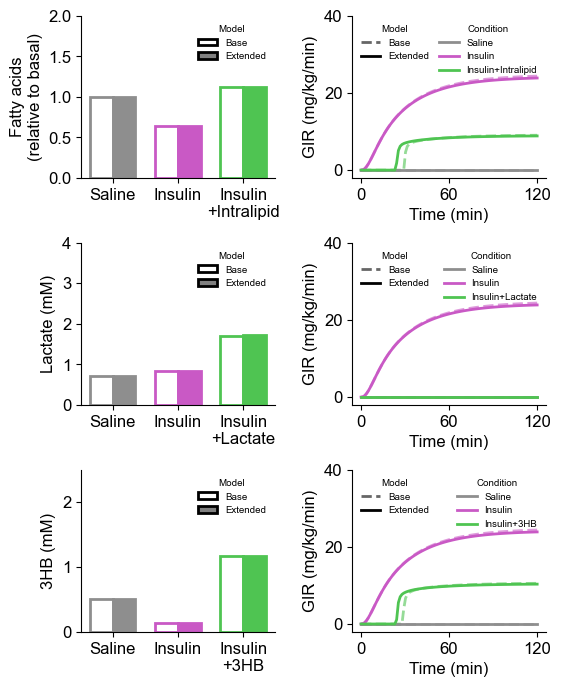

In [5]:
# Extract steady-state values (last time point) for Low Dose
# Base model
F_ss_base_low = {
    'Saline': x_saline_base['F'].iloc[-1],
    'Insulin': x_insulin_low_base['F'].iloc[-1],
    'Insulin\n+Intralipid': x_insulin_low_intralipid_base['F'].iloc[-1],
}
K_ss_base_low = {
    'Saline': x_saline_base['K'].iloc[-1],
    'Insulin': x_insulin_low_base['K'].iloc[-1],
    'Insulin\n+3HB': x_insulin_low_3HB_base['K'].iloc[-1],
}
L_ss_base_low = {
    'Saline': x_saline_base['L'].iloc[-1],
    'Insulin': x_insulin_low_base['L'].iloc[-1],
    'Insulin\n+Lactate': x_insulin_low_lactate_base['L'].iloc[-1],
}

# Extended model
F_ss_ext_low = {
    'Saline': x_saline_ext['F'].iloc[-1],
    'Insulin': x_insulin_low_ext['F'].iloc[-1],
    'Insulin\n+Intralipid': x_insulin_low_intralipid_ext['F'].iloc[-1],
}
K_ss_ext_low = {
    'Saline': x_saline_ext['K'].iloc[-1],
    'Insulin': x_insulin_low_ext['K'].iloc[-1],
    'Insulin\n+3HB': x_insulin_low_3HB_ext['K'].iloc[-1],
}
L_ss_ext_low = {
    'Saline': x_saline_ext['L'].iloc[-1],
    'Insulin': x_insulin_low_ext['L'].iloc[-1],
    'Insulin\n+Lactate': x_insulin_low_lactate_ext['L'].iloc[-1],
}

# Create 3x2 grid for low dose comparison
fig, axs = plt.subplots(3, 2, figsize=(6, 8), gridspec_kw={'width_ratios': [1, 1], 'hspace': 0.4, 'wspace': 0.4})

bar_width = 0.35
x_positions = np.arange(3)

# Row 1: Intralipid
# Fatty acids - Bar graph
conditions_F = list(F_ss_base_low.keys())
base_vals_F = list(F_ss_base_low.values())
ext_vals_F = list(F_ss_ext_low.values())

axs[0,0].bar(x_positions - bar_width/2, base_vals_F, bar_width, 
             color='white', edgecolor=colors, linewidth=2, label='Base')
axs[0,0].bar(x_positions + bar_width/2, ext_vals_F, bar_width,
             color=colors, edgecolor=colors, linewidth=2, label='Extended')
axs[0,0].set_ylabel('Fatty acids\n(relative to basal)')
axs[0,0].set_xticks(x_positions)
axs[0,0].set_xticklabels(conditions_F,)
axs[0,0].set_ylim(0, 2)

# GIR - Time plot
axs[0,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_insulin_low_base['time'], GIR_insulin_low_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_insulin_low_intralipid_base['time'], GIR_insulin_low_intralipid_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[0,1].plot(GIR_insulin_low_ext['time'], GIR_insulin_low_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[0,1].plot(GIR_insulin_low_intralipid_ext['time'], GIR_insulin_low_intralipid_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[0,1].set_ylabel('GIR (mg/kg/min)')
axs[0,1].set_xlabel('Time (min)')
axs[0,1].set_ylim(-2, 40)

# Row 2: Lactate
# Lactate - Bar graph
conditions_L = list(L_ss_base_low.keys())
base_vals_L = list(L_ss_base_low.values())
ext_vals_L = list(L_ss_ext_low.values())

axs[1,0].bar(x_positions - bar_width/2, base_vals_L, bar_width,
             color='white', edgecolor=colors, linewidth=2)
axs[1,0].bar(x_positions + bar_width/2, ext_vals_L, bar_width,
             color=colors, edgecolor=colors, linewidth=2)
axs[1,0].set_ylabel('Lactate (mM)')
axs[1,0].set_xticks(x_positions)
axs[1,0].set_xticklabels(conditions_L, )
axs[1,0].set_ylim(0, 4)

# GIR - Time plot
axs[1,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_insulin_low_base['time'], GIR_insulin_low_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_insulin_low_lactate_base['time'], GIR_insulin_low_lactate_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[1,1].plot(GIR_insulin_low_ext['time'], GIR_insulin_low_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[1,1].plot(GIR_insulin_low_lactate_ext['time'], GIR_insulin_low_lactate_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[1,1].set_ylabel('GIR (mg/kg/min)')
axs[1,1].set_xlabel('Time (min)')
axs[1,1].set_ylim(-2, 40)

# Row 3: 3HB
# 3HB - Bar graph
conditions_K = list(K_ss_base_low.keys())
base_vals_K = list(K_ss_base_low.values())
ext_vals_K = list(K_ss_ext_low.values())

axs[2,0].bar(x_positions - bar_width/2, base_vals_K, bar_width,
             color='white', edgecolor=colors, linewidth=2)
axs[2,0].bar(x_positions + bar_width/2, ext_vals_K, bar_width,
             color=colors, edgecolor=colors, linewidth=2)
axs[2,0].set_ylabel('3HB (mM)')
axs[2,0].set_xticks(x_positions)
axs[2,0].set_xticklabels(conditions_K, )
axs[2,0].set_ylim(0, 2.5)

# GIR - Time plot
axs[2,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_insulin_low_base['time'], GIR_insulin_low_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_insulin_low_3HB_base['time'], GIR_insulin_low_3HB_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[2,1].plot(GIR_insulin_low_ext['time'], GIR_insulin_low_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[2,1].plot(GIR_insulin_low_3HB_ext['time'], GIR_insulin_low_3HB_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[2,1].set_ylabel('GIR (mg/kg/min)')
axs[2,1].set_xlabel('Time (min)')
axs[2,1].set_ylim(-2, 40)

# Set x-axis ticks for time plots only
for i in range(3):
    axs[i,1].set_xticks([0, 60, 120])

# Create custom legends
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Black and white legend for model type (bar plots - left column)
model_legend_bar = [
    Patch(facecolor='white', edgecolor='black', linewidth=2, label='Base'),
    Patch(facecolor='gray', edgecolor='black', linewidth=2, label='Extended')
]

# Black and white legend for model type (line plots - right column)
model_legend_line = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, alpha=0.6, label='Base'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='Extended')
]

# Colored legend for conditions
condition_labels_F = ['Saline', 'Insulin', 'Insulin+Intralipid']
condition_labels_L = ['Saline', 'Insulin', 'Insulin+Lactate']
condition_labels_K = ['Saline', 'Insulin', 'Insulin+3HB']

condition_legend_F = [Line2D([0], [0], color=colors[i], linewidth=2, label=condition_labels_F[i]) for i in range(3)]
condition_legend_L = [Line2D([0], [0], color=colors[i], linewidth=2, label=condition_labels_L[i]) for i in range(3)]
condition_legend_K = [Line2D([0], [0], color=colors[i], linewidth=2, label=condition_labels_K[i]) for i in range(3)]

# Add legends to bar plots (left column)
axs[0,0].legend(handles=model_legend_bar, frameon=False, fontsize=7, loc='upper right', title='Model', title_fontsize=7)
axs[1,0].legend(handles=model_legend_bar, frameon=False, fontsize=7, loc='upper right', title='Model', title_fontsize=7)
axs[2,0].legend(handles=model_legend_bar, frameon=False, fontsize=7, loc='upper right', title='Model', title_fontsize=7)

# Add model legends to line plots (right column) - upper left
leg1_0 = axs[0,1].legend(handles=model_legend_line, frameon=False, fontsize=7, loc='upper left', title='Model', title_fontsize=7)
leg1_1 = axs[1,1].legend(handles=model_legend_line, frameon=False, fontsize=7, loc='upper left', title='Model', title_fontsize=7)
leg1_2 = axs[2,1].legend(handles=model_legend_line, frameon=False, fontsize=7, loc='upper left', title='Model', title_fontsize=7)

# Add colored condition legends to line plots (right column) - upper right
axs[0,1].add_artist(leg1_0)
axs[0,1].legend(handles=condition_legend_F, frameon=False, fontsize=7, loc='upper right', title='Condition', title_fontsize=7)
axs[1,1].add_artist(leg1_1)
axs[1,1].legend(handles=condition_legend_L, frameon=False, fontsize=7, loc='upper right', title='Condition', title_fontsize=7)
axs[2,1].add_artist(leg1_2)
axs[2,1].legend(handles=condition_legend_K, frameon=False, fontsize=7, loc='upper right', title='Condition', title_fontsize=7)

sns.despine()
plt.savefig('./output/hyperinsulinemic_clamp_low_dose_comparison.svg', bbox_inches='tight')
plt.show()

## High Dose Insulin Clamp (2.5 mU)

In [6]:
# =============================================================================
# Extended Model - High Dose
# =============================================================================

# Insulin only
x_insulin_high_ext, GIR_insulin_high_ext = insulin_clamp_dynamic_ext(vI_high_ext, time, 1.0, p=p_ext)

# Insulin + Intralipid
x_insulin_high_intralipid_ext, GIR_insulin_high_intralipid_ext = insulin_clamp_dynamic_ext(
    vI_high_ext, time, 1.0, p=p_ext, R_fatty_acids=R_fatty_acids)

# Insulin + 3HB
x_insulin_high_3HB_ext, GIR_insulin_high_3HB_ext = insulin_clamp_dynamic_ext(
    vI_high_ext, time, 1.0, p=p_ext, R_3HB=R_3HB)

# Insulin + Lactate
x_insulin_high_lactate_ext, GIR_insulin_high_lactate_ext = insulin_clamp_dynamic_ext(
    vI_high_ext, time, 1.0, p=p_ext, R_lactate=R_lactate)

# =============================================================================
# Base Model - High Dose
# =============================================================================

# Insulin only
x_insulin_high_base, GIR_insulin_high_base = insulin_clamp_dynamic_base(vI_high_base, time, 1.0, p=p_base)

# Insulin + Intralipid
x_insulin_high_intralipid_base, GIR_insulin_high_intralipid_base = insulin_clamp_dynamic_base(
    vI_high_base, time, 1.0, p=p_base, R_fatty_acids=R_fatty_acids)

# Insulin + 3HB
x_insulin_high_3HB_base, GIR_insulin_high_3HB_base = insulin_clamp_dynamic_base(
    vI_high_base, time, 1.0, p=p_base, R_3HB=R_3HB)

# Insulin + Lactate
x_insulin_high_lactate_base, GIR_insulin_high_lactate_base = insulin_clamp_dynamic_base(
    vI_high_base, time, 1.0, p=p_base, R_lactate=R_lactate)

# =============================================================================
# Scale metabolites to physiological units
# =============================================================================

# Extended model
for df in [x_insulin_high_ext, x_insulin_high_intralipid_ext, 
           x_insulin_high_3HB_ext, x_insulin_high_lactate_ext]:
    df['K'] = df['K'] * 0.5  # mM
    df['L'] = df['L'] * 0.7  # mM

# Base model
for df in [x_insulin_high_base, x_insulin_high_intralipid_base,
           x_insulin_high_3HB_base, x_insulin_high_lactate_base]:
    df['K'] = df['K'] * 0.5  # mM
    df['L'] = df['L'] * 0.7  # mM

# Scale GIR with common scaling factor
for df in [GIR_insulin_high_ext, GIR_insulin_high_intralipid_ext,
           GIR_insulin_high_3HB_ext, GIR_insulin_high_lactate_ext,
           GIR_insulin_high_base, GIR_insulin_high_intralipid_base,
           GIR_insulin_high_3HB_base, GIR_insulin_high_lactate_base]:
    df['GIR'] = df['GIR'] * sGIR

## Comparison Plots - High Dose Insulin (2.5 mU)

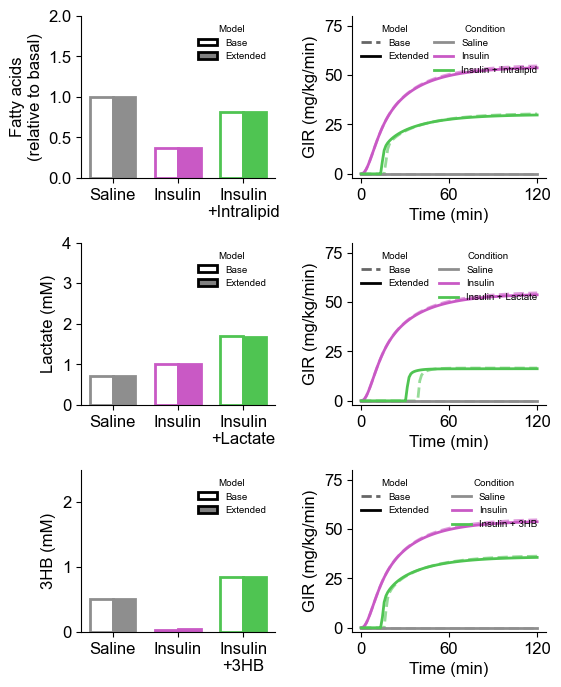

In [7]:
# Extract steady-state values (last time point) for High Dose
# Base model
F_ss_base_high = {
    'Saline': x_saline_base['F'].iloc[-1],
    'Insulin': x_insulin_high_base['F'].iloc[-1],
    'Insulin\n+Intralipid': x_insulin_high_intralipid_base['F'].iloc[-1],
}
K_ss_base_high = {
    'Saline': x_saline_base['K'].iloc[-1],
    'Insulin': x_insulin_high_base['K'].iloc[-1],
    'Insulin\n+3HB': x_insulin_high_3HB_base['K'].iloc[-1],
}
L_ss_base_high = {
    'Saline': x_saline_base['L'].iloc[-1],
    'Insulin': x_insulin_high_base['L'].iloc[-1],
    'Insulin\n+Lactate': x_insulin_high_lactate_base['L'].iloc[-1],
}

# Extended model
F_ss_ext_high = {
    'Saline': x_saline_ext['F'].iloc[-1],
    'Insulin': x_insulin_high_ext['F'].iloc[-1],
    'Insulin\n+Intralipid': x_insulin_high_intralipid_ext['F'].iloc[-1],
}
K_ss_ext_high = {
    'Saline': x_saline_ext['K'].iloc[-1],
    'Insulin': x_insulin_high_ext['K'].iloc[-1],
    'Insulin\n+3HB': x_insulin_high_3HB_ext['K'].iloc[-1],
}
L_ss_ext_high = {
    'Saline': x_saline_ext['L'].iloc[-1],
    'Insulin': x_insulin_high_ext['L'].iloc[-1],
    'Insulin\n+Lactate': x_insulin_high_lactate_ext['L'].iloc[-1],
}

# Create 3x2 grid for high dose comparison
fig, axs = plt.subplots(3, 2, figsize=(6, 8), gridspec_kw={'width_ratios': [1, 1], 'hspace': 0.4, 'wspace': 0.4})

bar_width = 0.35
x_positions = np.arange(3)

# Row 1: Intralipid
# Fatty acids - Bar graph
conditions_F = list(F_ss_base_high.keys())
base_vals_F = list(F_ss_base_high.values())
ext_vals_F = list(F_ss_ext_high.values())

axs[0,0].bar(x_positions - bar_width/2, base_vals_F, bar_width, 
             color='white', edgecolor=colors, linewidth=2, label='Base')
axs[0,0].bar(x_positions + bar_width/2, ext_vals_F, bar_width,
             color=colors, edgecolor=colors, linewidth=2, label='Extended')
axs[0,0].set_ylabel('Fatty acids\n(relative to basal)')
axs[0,0].set_xticks(x_positions)
axs[0,0].set_xticklabels(conditions_F)
axs[0,0].set_ylim(0, 2)

# GIR - Time plot
axs[0,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_insulin_high_base['time'], GIR_insulin_high_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_insulin_high_intralipid_base['time'], GIR_insulin_high_intralipid_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[0,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[0,1].plot(GIR_insulin_high_ext['time'], GIR_insulin_high_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[0,1].plot(GIR_insulin_high_intralipid_ext['time'], GIR_insulin_high_intralipid_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[0,1].set_ylabel('GIR (mg/kg/min)')
axs[0,1].set_xlabel('Time (min)')
axs[0,1].set_ylim(-2, 80)

# Row 2: Lactate
# Lactate - Bar graph
conditions_L = list(L_ss_base_high.keys())
base_vals_L = list(L_ss_base_high.values())
ext_vals_L = list(L_ss_ext_high.values())

axs[1,0].bar(x_positions - bar_width/2, base_vals_L, bar_width,
             color='white', edgecolor=colors, linewidth=2)
axs[1,0].bar(x_positions + bar_width/2, ext_vals_L, bar_width,
             color=colors, edgecolor=colors, linewidth=2)
axs[1,0].set_ylabel('Lactate (mM)')
axs[1,0].set_xticks(x_positions)
axs[1,0].set_xticklabels(conditions_L)
axs[1,0].set_ylim(0, 4)

# GIR - Time plot
axs[1,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_insulin_high_base['time'], GIR_insulin_high_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_insulin_high_lactate_base['time'], GIR_insulin_high_lactate_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[1,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[1,1].plot(GIR_insulin_high_ext['time'], GIR_insulin_high_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[1,1].plot(GIR_insulin_high_lactate_ext['time'], GIR_insulin_high_lactate_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[1,1].set_ylabel('GIR (mg/kg/min)')
axs[1,1].set_xlabel('Time (min)')
axs[1,1].set_ylim(-2, 80)

# Row 3: 3HB
# 3HB - Bar graph
conditions_K = list(K_ss_base_high.keys())
base_vals_K = list(K_ss_base_high.values())
ext_vals_K = list(K_ss_ext_high.values())

axs[2,0].bar(x_positions - bar_width/2, base_vals_K, bar_width,
             color='white', edgecolor=colors, linewidth=2)
axs[2,0].bar(x_positions + bar_width/2, ext_vals_K, bar_width,
             color=colors, edgecolor=colors, linewidth=2)
axs[2,0].set_ylabel('3HB (mM)')
axs[2,0].set_xticks(x_positions)
axs[2,0].set_xticklabels(conditions_K,)
axs[2,0].set_ylim(0, 2.5)

# GIR - Time plot
axs[2,1].plot(GIR_saline_base['time'], GIR_saline_base['GIR'], 
              color=colors[0], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_insulin_high_base['time'], GIR_insulin_high_base['GIR'], 
              color=colors[1], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_insulin_high_3HB_base['time'], GIR_insulin_high_3HB_base['GIR'], 
              color=colors[2], linestyle='--', linewidth=2, alpha=0.6)
axs[2,1].plot(GIR_saline_ext['time'], GIR_saline_ext['GIR'], 
              color=colors[0], linestyle='-', linewidth=2)
axs[2,1].plot(GIR_insulin_high_ext['time'], GIR_insulin_high_ext['GIR'], 
              color=colors[1], linestyle='-', linewidth=2)
axs[2,1].plot(GIR_insulin_high_3HB_ext['time'], GIR_insulin_high_3HB_ext['GIR'], 
              color=colors[2], linestyle='-', linewidth=2)
axs[2,1].set_ylabel('GIR (mg/kg/min)')
axs[2,1].set_xlabel('Time (min)')
axs[2,1].set_ylim(-2, 80)

# Set x-axis ticks for time plots only
for i in range(3):
    axs[i,1].set_xticks([0, 60, 120])

# Create custom legends
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Black and white legend for model type (bar plots - left column)
model_legend_bar = [
    Patch(facecolor='white', edgecolor='black', linewidth=2, label='Base'),
    Patch(facecolor='gray', edgecolor='black', linewidth=2, label='Extended')
]

# Black and white legend for model type (line plots - right column)
model_legend_line = [
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, alpha=0.6, label='Base'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='Extended')
]

# Colored legend for conditions
condition_labels_F = ['Saline', 'Insulin', 'Insulin + Intralipid']
condition_labels_L = ['Saline', 'Insulin', 'Insulin + Lactate']
condition_labels_K = ['Saline', 'Insulin', 'Insulin + 3HB']

condition_legend_F = [Line2D([0], [0], color=colors[i], linewidth=2, label=condition_labels_F[i]) for i in range(3)]
condition_legend_L = [Line2D([0], [0], color=colors[i], linewidth=2, label=condition_labels_L[i]) for i in range(3)]
condition_legend_K = [Line2D([0], [0], color=colors[i], linewidth=2, label=condition_labels_K[i]) for i in range(3)]

# Add legends to bar plots (left column)
axs[0,0].legend(handles=model_legend_bar, frameon=False, fontsize=7, loc='upper right', title='Model', title_fontsize=7)
axs[1,0].legend(handles=model_legend_bar, frameon=False, fontsize=7, loc='upper right', title='Model', title_fontsize=7)
axs[2,0].legend(handles=model_legend_bar, frameon=False, fontsize=7, loc='upper right', title='Model', title_fontsize=7)

# Add model legends to line plots (right column) - upper left
leg1_0 = axs[0,1].legend(handles=model_legend_line, frameon=False, fontsize=7, loc='upper left', title='Model', title_fontsize=7)
leg1_1 = axs[1,1].legend(handles=model_legend_line, frameon=False, fontsize=7, loc='upper left', title='Model', title_fontsize=7)
leg1_2 = axs[2,1].legend(handles=model_legend_line, frameon=False, fontsize=7, loc='upper left', title='Model', title_fontsize=7)

# Add colored condition legends to line plots (right column) - upper right
axs[0,1].add_artist(leg1_0)
axs[0,1].legend(handles=condition_legend_F, frameon=False, fontsize=7, loc='upper right', title='Condition', title_fontsize=7)
axs[1,1].add_artist(leg1_1)
axs[1,1].legend(handles=condition_legend_L, frameon=False, fontsize=7, loc='upper right', title='Condition', title_fontsize=7)
axs[2,1].add_artist(leg1_2)
axs[2,1].legend(handles=condition_legend_K, frameon=False, fontsize=7, loc='upper right', title='Condition', title_fontsize=7)

sns.despine()
plt.savefig('./output/hyperinsulinemic_clamp_high_dose_comparison.svg', bbox_inches='tight')
plt.show()